In [1]:
import numpy as np
import torch
import pandas as pd
from __init__ import PRP
import sys
sys.path.append(f'{PRP}/Results/analysis_scripts/')
from metrics import get_density_at_surface_tensor
import einops
import torch.nn as nn
from ShapeChecker import ShapeCheck
from sklearn.cluster import KMeans

import torch
import torch.distributions as D
import torch.nn as nn
import torch.optim as optim
from tqdm import trange
from safetensors.torch import load_file
from torch.func import grad



# Load Data

In [2]:
base = f'{PRP}/data/mini_dino_1_4_degree_coarse_240125/'
files = pd.DataFrame([{'toce' : f'{base}/{i:05d}.toce.npy', 'soce' : f'{base}/{i:05d}.soce.npy'} for i in range(11)])

In [3]:
class Preprocessor :
    def __init__(self, shapes, mean, std, levels) : 
        """
            mean (1, channels)
        """
        self.sc = ShapeCheck(shapes, 'n k i j')
        self.mean = mean 
        self.std = std
        self.levels = levels 

    def normalize(self, data) :
        """
           data (b, channels)

        """
        return (data - self.mean)/self.std

    def unnormalize(self, data) :
        """
           data (b, channels)

        """
        return (data*self.std) + self.mean
    
    def concat(self, toce, soce) : 
        assert toce.shape[-1] == self.levels
        data = self.sc.rearrange([toce, soce], 'm b k -> b (m k)')
        self.sc.update(data.shape, '_ c')
        return data
    
    def unconcat(self, data) : 
        toce = data[:, :self.levels]
        soce = data[:, self.levels:]
        return toce, soce
    
    def flatten(self, field) : 
        return self.sc.rearrange(field, 'n k i j -> (n i j) k')

    def unflatten(self, field) : 
        return self.sc.rearrange(field, '(n i j) k -> n k i j')
    
        
    def forward(self, toce, soce) : 
        data = self.concat(toce, soce)
        return self.normalize(data)
    
    def backward(self, data) : 
        data = self.unnormalize(data)
        toce, soce = self.unconcat(data)      
        return toce, soce


p, levels = 10, 35
stats = load_file('profile_states.safetensor')
toce = torch.tensor(np.load(files.iloc[0]['toce'])[:levels, p:-p, p:-p][None])
soce = torch.tensor(np.load(files.iloc[0]['soce'])[:levels, p:-p, p:-p][None])

density = get_density_at_surface_tensor(toce, soce)

norm = Preprocessor(toce.shape, stats['mean'], stats['std'], levels)

data_flat_normalised = norm.forward(norm.flatten(toce), norm.flatten(soce))

In [4]:
avg_density_profile = density.mean(axis=(0, 2, 3))

<bound method FigureBase.suptitle of <Figure size 2000x500 with 3 Axes>>

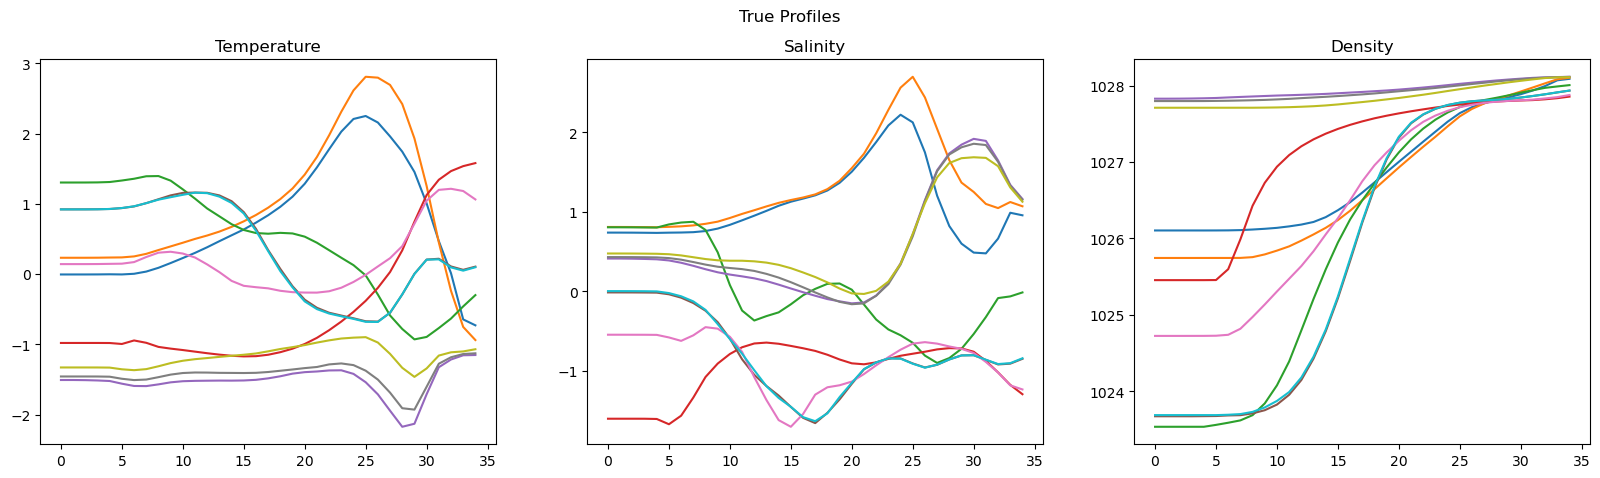

In [5]:
fig, axs = plt.subplots(1,3,figsize=(20,5))
fig.suptitle('True Profiles')
rindex = torch.randint(0, data_flat_normalised.shape[0], (10,))
axs[0].set_title('Temperature')
axs[0].plot(data_flat_normalised[rindex, :levels].T)
axs[1].set_title('Salinity')
axs[1].plot(data_flat_normalised[rindex, levels:].T)
axs[2].set_title('Density')
axs[2].plot(norm.flatten(density)[rindex, :].T)
fig.suptitle

In [6]:
km = KMeans(5)
clusters = km.fit_predict(norm.flatten(density))

/var/folders/v0/69j0mqn17s50r4rf2hscwsyw0000gp/T/ipykernel_66907/3823533351.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set1', n_clusters)


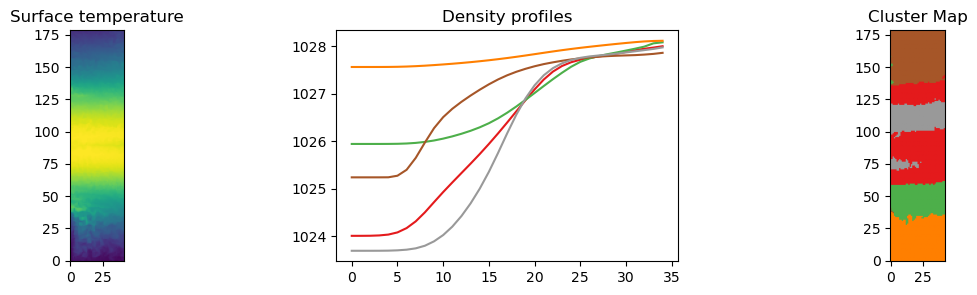

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3))

axs[0].set_title('Surface temperature')
axs[0].imshow(toce[0, 0])

n_clusters = km.n_clusters  # or 8
cmap = plt.cm.get_cmap('Set1', n_clusters)

# --- Line plot with colors coming from the same cmap ---
axs[1].set_title('Density profiles')
axs[1].set_prop_cycle(color=[cmap(i) for i in range(n_clusters)])
axs[1].plot(km.cluster_centers_.T)   # one line per cluster

# --- Cluster map with same cmap/index convention ---
axs[2].set_title('Cluster Map')
cluster_map = norm.sc.rearrange(clusters, '(n i j) -> n i j')
axs[2].imshow(
    cluster_map[0],
    cmap=cmap,
    vmin=0,
    vmax=n_clusters - 1,
)

# Train generative model

In [11]:
class Block(nn.Module) : 
    def __init__(self, in_ch, out_ch, activation=nn.ReLU, skip_co=False, norm=nn.Identity) : 
        super().__init__()
        self.skip_co = skip_co
        self.proj = nn.Linear(in_ch, out_ch, bias=True)
        self.act = activation()
        self.norm =  norm(out_ch)
    
    def forward(self, x) : 
        r = self.norm(self.act(self.proj(x)))
        if self.skip_co : 
            r = r + x
        return r
    
class Net(nn.Module) : 
    def __init__(self, in_ch) : 
        super().__init__()
        m =  256
        norm = nn.Identity
        act = nn.SELU
        blocks = [Block(in_ch+1, m, norm=norm, activation=act),
                       Block(m, m, skip_co=True, norm=norm, activation=act),
                       Block(m, m, skip_co=True, norm=norm, activation=act),
                       Block(m, in_ch, activation=nn.Identity)]
        self.blocks = nn.Sequential(*blocks)
        
    def forward(self, x, t) : 
        
        return self.blocks(torch.cat([x, t], dim=1))

In [12]:
d = norm.sc.shape_dict['c']


prior = D.MultivariateNormal(torch.zeros(d), torch.eye(d, d))

targets = data_flat_normalised
N = targets.shape[0]
priors = prior.sample((N,))

In [13]:
# In practice we need to sample t, z, and compute x 
u_theta = Net(d)
opt = optim.Adam(u_theta.parameters(), lr=0.001)
epochs = 5000
losses = torch.zeros(epochs)

for epoch in trange(epochs) :
    ts = torch.rand((N, 1))
    xs = ts*targets + (1-ts)*priors # sample x from p(x | t, z)
    us = targets - priors
    opt.zero_grad()
    loss = torch.nn.functional.mse_loss(u_theta(xs, ts), us)
    loss.backward()
    opt.step()
    losses[epoch] = loss.item()

  0%|          | 0/5000 [00:00<?, ?it/s]

100%|██████████| 5000/5000 [03:29<00:00, 23.91it/s]


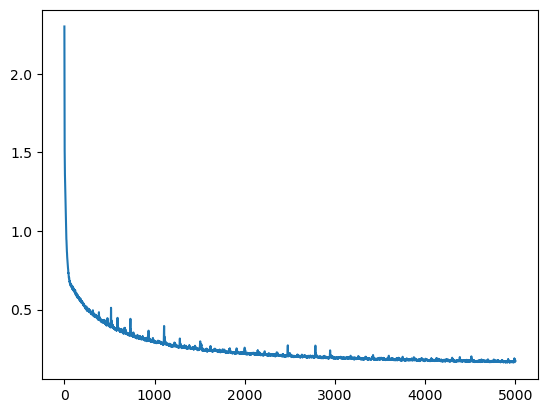

In [345]:
plt.plot(losses)

# Generate profile 

In [862]:
S = 10
x_init = prior.sample((S,))

with torch.no_grad() :
    x, t= x_init.clone(), torch.zeros((S,1))
    dt = 0.001
    for i in range(int(1 // dt) +1 ) : 
        x = x + dt*u_theta(x,t)
        t = t + dt

<bound method FigureBase.suptitle of <Figure size 2000x500 with 3 Axes>>

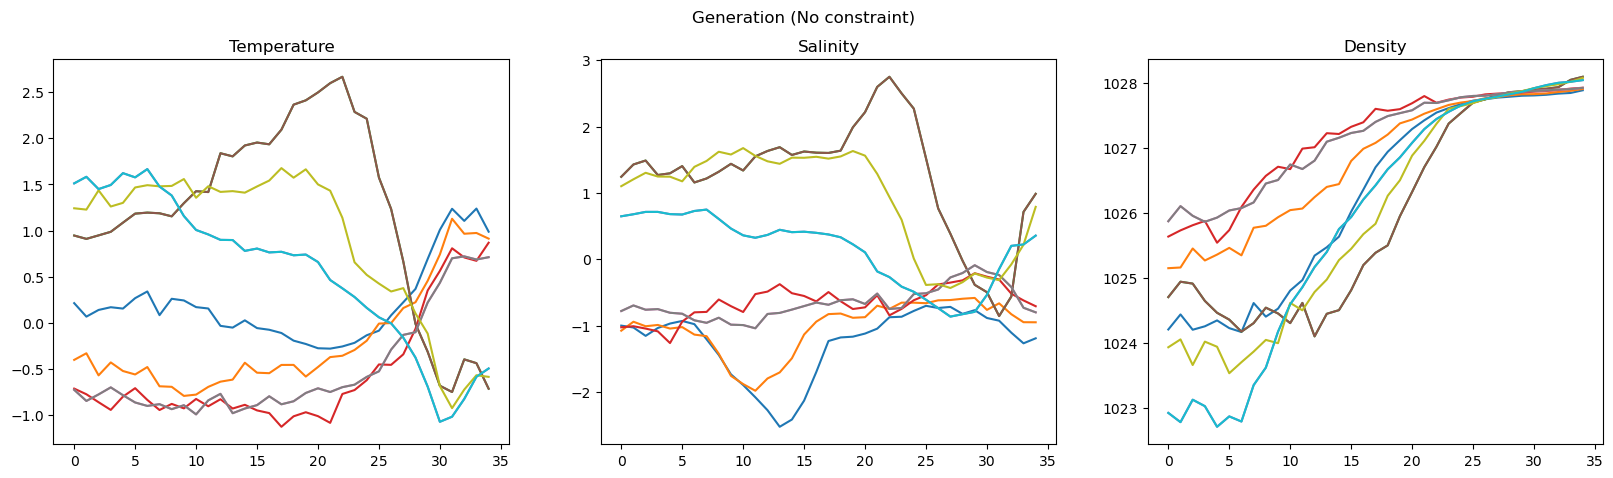

In [863]:
toce_gen, soce_gen = norm.backward(x)
density_gen = get_density_at_surface_tensor(toce_gen, soce_gen)

fig, axs = plt.subplots(1,3,figsize=(20,5))
fig.suptitle('Generation (No constraint)')
rindex = torch.randint(0, x.shape[0], (10,))
axs[0].set_title('Temperature')
axs[0].plot(x[rindex, :levels].T)
axs[1].set_title('Salinity')
axs[1].plot(x[rindex, levels:].T)
axs[2].set_title('Density')
axs[2].plot(density_gen[rindex, :].T)
fig.suptitle

# Apply constraints 

In [58]:
from scipy.optimize import isotonic_regression
from scipy.optimize import linear_sum_assignment

def g(x) :
    """
        x (b, k)
    """
    toce_gen, soce_gen = norm.backward(x)
    density = get_density_at_surface_tensor(toce_gen, soce_gen)
    return density

In [ ]:
class ClusterConstraint() : 
    name = "Clusters"
    cl_c = torch.tensor(km.cluster_centers_)
    weights = torch.ones(len(cl_c)) / len(cl_c)
    
    @staticmethod
    def closest_cluster(gx, cl_c) : 
        gx = gx.detach()
        count_clusters = (ClusterConstraint.weights * gx.shape[0]).to(int)
        count_clusters[0] += gx.shape[0] - count_clusters.sum()
        r_cl_c = torch.concat([torch.stack([ClusterConstraint.cl_c[i]]*n) for i, n in enumerate(count_clusters)]).to(gx.dtype)
        cost = ((r_cl_c[None] - gx[:, None])**2).sum(axis=-1)
        row_index, col_index = linear_sum_assignment(cost)
        return r_cl_c[col_index]
    
    @staticmethod
    @torch.no_grad()
    def projection(gx):
        return ClusterConstraint.closest_cluster(gx, ClusterConstraint.cl_c)
    

    
class IsotonicConstraint() : 
    name = 'Isotonic'

    @staticmethod
    def isotonic(gx) :
        return torch.tensor(np.stack([isotonic_regression(dg.detach().clone()).x for dg in gx]), dtype=gx.dtype)
    
    @staticmethod
    @torch.no_grad()
    def projection(gx):
        return IsotonicConstraint.isotonic(gx)



class DensityProfile() : 
    name = 'Density Profile'

    @staticmethod
    @torch.no_grad()
    def projection(gx):
        return stats['avg_density'][None].repeat((gx.shape[0], 1)).to(gx.device, gx.dtype)

def L_r(x, z, lbd, rho) : 
    """
        x (n i j k) -> g(x) (n k)
        z (n k)
        lbd (k)
        rho (1)
    """
    E_d_sq = ((g(x) - z)**2).sum(axis=-1).mean()
    E_d = (g(x) - z).mean(axis=0) # (k)
    return rho*E_d_sq + lbd@E_d

In [108]:
h = IsotonicConstraint()

prior = D.MultivariateNormal(torch.zeros(d), torch.eye(d, d))
x = prior.sample((10,))

In [109]:
rho

tensor([[457.0002]], requires_grad=True)

In [110]:
S = 10
dt = 0.001
eta, eta_rho = 1.0, 1e-4
epsilon = 1e-7

x = prior.sample((S,))
x.requires_grad_(True)
t = torch.zeros((x.shape[0],1))
lbd = torch.zeros(1, g(x).shape[1], requires_grad=True)# Same lbd for full batch
rho = torch.full((1,1), 0.01, requires_grad=True)
metrics = []

for i in (pbar := trange(int(1 // dt))):
    z = h.projection(g(x) + lbd / (2*rho))
    l = L_r(x, z, lbd, rho)
    l.backward()

    with torch.no_grad():
        x += dt*(u_theta(x.detach(), t) - x.grad)
        lbd += eta*lbd.grad
        rho += eta_rho*rho.grad
        rho.clamp_(min=0.01)
        t = t + dt
    x.grad, lbd.grad = None, None
    metric = {'t' : t.mean().item(), 'mean(lbd)' : lbd.mean().item()}
    pbar.set_postfix(metric)
    metrics.append(metric)

x = x.detach()
metrics = pd.DataFrame(metrics)

100%|██████████| 999/999 [00:02<00:00, 389.06it/s, t=0.999, mean(lbd)=0.000155] 


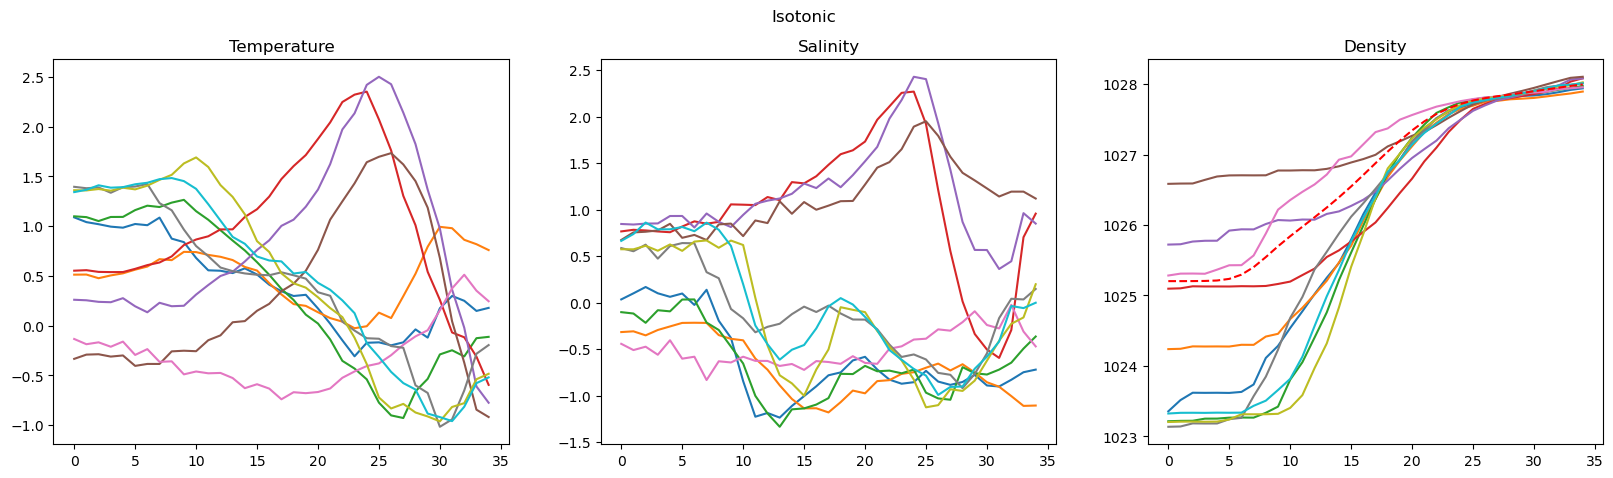

In [111]:
toce_gen, soce_gen = norm.backward(x)
density_gen = get_density_at_surface_tensor(toce_gen, soce_gen)

fig, axs = plt.subplots(1,3,figsize=(20,5))
fig.suptitle(f'{h.name}')
rindex = torch.randperm(x.shape[0])[:20]
axs[0].set_title('Temperature')
axs[0].plot(x[rindex, :levels].T)
axs[1].set_title('Salinity')
axs[1].plot(x[rindex, levels:].T)
axs[2].set_title('Density')
axs[2].plot(density_gen[rindex, :].T)
axs[2].plot(stats['avg_density'], c='r', linestyle='dashed')
#axs[2].plot(h.cl_c.T, linestyle='dashed')